<a href="https://colab.research.google.com/github/yawarabbasmalik/Key-Indicators-of-Heart-Disease/blob/main/Key_Indicators_of_Heart_Disease.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objs as go
import plotly.subplots as sp
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


In [ ]:
# read the dataset into a pandas DataFrame
df = pd.read_csv('heart_2020_cleaned.csv')

In [ ]:
df.head()

,BMI,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,AgeCategory,Race,Diabetic,PhysicalActivity,GenHealth,SleepTime,Asthma,KidneyDisease,SkinCancer,HeartDisease
0,16.60,Yes,No,No,3,30,No,Female,55-59,White,Yes,Yes,Very good,5,Yes,No,Yes,No
1,20.34,No,No,Yes,0,0,No,Female,80 or older,White,No,Yes,Very good,7,No,No,No,No
2,26.58,Yes,No,No,20,30,No,Male,65-69,White,Yes,Yes,Fair,8,Yes,No,No,No
3,24.21,No,No,No,0,0,No,Female,75-79,White,No,No,Good,6,No,No,Yes,No
4,23.71,No,No,No,28,0,Yes,Female,40-44,White,No,Yes,Very good,8,No,No,No,No


In [ ]:
# define the mapping dictionary
age_mapping = {'55-59': 57, '80 or older': 80, '65-69': 67, '75-79': 77, '40-44': 42, '70-74': 72,
               '60-64': 62, '50-54': 52, '45-49': 47, '18-24': 21, '35-39': 37, '30-34': 32, '25-29': 27}

In [ ]:
# map the AgeCategory column to the numerical values using the age_mapping dictionary
df['AgeCategory'] = df['AgeCategory'].map(age_mapping)

In [ ]:
df.head()

,BMI,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,AgeCategory,Race,Diabetic,PhysicalActivity,GenHealth,SleepTime,Asthma,KidneyDisease,SkinCancer,HeartDisease
0,16.60,Yes,No,No,3,30,No,Female,57,White,Yes,Yes,Very good,5,Yes,No,Yes,No
1,20.34,No,No,Yes,0,0,No,Female,80,White,No,Yes,Very good,7,No,No,No,No
2,26.58,Yes,No,No,20,30,No,Male,67,White,Yes,Yes,Fair,8,Yes,No,No,No
3,24.21,No,No,No,0,0,No,Female,77,White,No,No,Good,6,No,No,Yes,No
4,23.71,No,No,No,28,0,Yes,Female,42,White,No,Yes,Very good,8,No,No,No,No


In [ ]:
df.describe()

,BMI,PhysicalHealth,MentalHealth,AgeCategory,SleepTime
count,319795.000000,319795.00000,319795.000000,319795.000000,319795.000000
mean,28.325399,3.37171,3.898366,54.355759,7.097075
std,6.356100,7.95085,7.955235,17.720429,1.436007
min,12.020000,0.00000,0.000000,21.000000,1.000000
25%,24.030000,0.00000,0.000000,42.000000,6.000000
50%,27.340000,0.00000,0.000000,57.000000,7.000000
75%,31.420000,2.00000,3.000000,67.000000,8.000000
max,94.850000,30.00000,30.000000,80.000000,24.000000


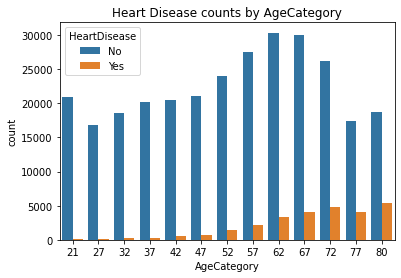

In [ ]:
# Bar plot of HeartDisease counts by AgeCategory
sns.countplot(x="AgeCategory", hue="HeartDisease", data=df)
plt.title("Heart Disease counts by AgeCategory")
plt.show()

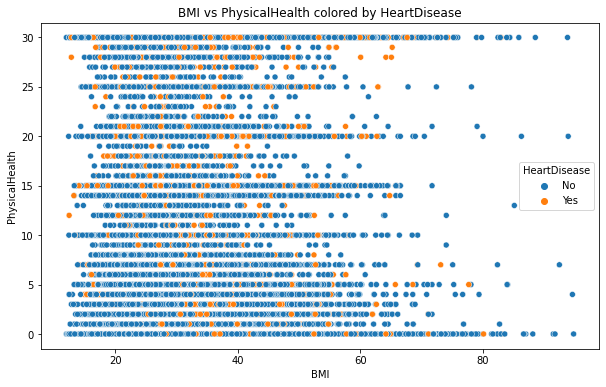

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x="BMI", y="PhysicalHealth", hue="HeartDisease", data=df)
plt.title("BMI vs PhysicalHealth colored by HeartDisease")
plt.show()

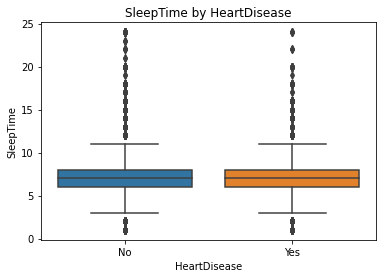

In [ ]:
# Box plot of SleepTime by HeartDisease
sns.boxplot(x="HeartDisease", y="SleepTime", data=df)
plt.title("SleepTime by HeartDisease")
plt.show()

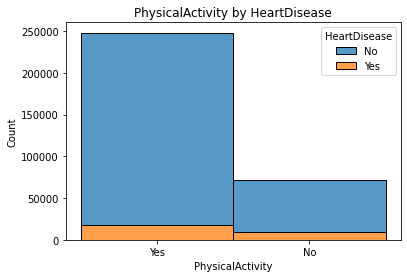

In [ ]:
# Histogram of PhysicalActivity by HeartDisease
sns.histplot(data=df, x="PhysicalActivity", hue="HeartDisease", multiple="stack")
plt.title("PhysicalActivity by HeartDisease")
plt.show()

In [ ]:
df.head()

,BMI,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,AgeCategory,Race,Diabetic,PhysicalActivity,GenHealth,SleepTime,Asthma,KidneyDisease,SkinCancer,HeartDisease
0,16.60,Yes,No,No,3,30,No,Female,57,White,Yes,Yes,Very good,5,Yes,No,Yes,No
1,20.34,No,No,Yes,0,0,No,Female,80,White,No,Yes,Very good,7,No,No,No,No
2,26.58,Yes,No,No,20,30,No,Male,67,White,Yes,Yes,Fair,8,Yes,No,No,No
3,24.21,No,No,No,0,0,No,Female,77,White,No,No,Good,6,No,No,Yes,No
4,23.71,No,No,No,28,0,Yes,Female,42,White,No,Yes,Very good,8,No,No,No,No


In [ ]:
df.shape

(319795, 18)

In [ ]:
# Check for null values
if df.isnull().sum().sum() > 0:
    # Remove rows with null values
    df = df.dropna()

# Check for duplicates
if df.duplicated().sum() > 0:
    # Remove duplicate rows
    df = df.drop_duplicates()

# Print the number of rows and columns after removing null values and duplicates
print("Number of rows and columns after removing null values and duplicates:", df.shape)

Number of rows and columns after removing null values and duplicates: (301717, 18)


In [ ]:
df.head()

,BMI,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,AgeCategory,Race,Diabetic,PhysicalActivity,GenHealth,SleepTime,Asthma,KidneyDisease,SkinCancer,HeartDisease
0,16.60,Yes,No,No,3,30,No,Female,57,White,Yes,Yes,Very good,5,Yes,No,Yes,No
1,20.34,No,No,Yes,0,0,No,Female,80,White,No,Yes,Very good,7,No,No,No,No
2,26.58,Yes,No,No,20,30,No,Male,67,White,Yes,Yes,Fair,8,Yes,No,No,No
3,24.21,No,No,No,0,0,No,Female,77,White,No,No,Good,6,No,No,Yes,No
4,23.71,No,No,No,28,0,Yes,Female,42,White,No,Yes,Very good,8,No,No,No,No


In [ ]:
le = LabelEncoder()

# Encode categorical columns using LabelEncoder
df['Smoking'] = le.fit_transform(df['Smoking'])
df['AlcoholDrinking'] = le.fit_transform(df['AlcoholDrinking'])
df['Stroke'] = le.fit_transform(df['Stroke'])
df['DiffWalking'] = le.fit_transform(df['DiffWalking'])
df['Sex'] = le.fit_transform(df['Sex'])
df['Race'] = le.fit_transform(df['Race'])
df['Diabetic'] = le.fit_transform(df['Diabetic'])
df['PhysicalActivity'] = le.fit_transform(df['PhysicalActivity'])
df['GenHealth'] = le.fit_transform(df['GenHealth'])
df['Asthma'] = le.fit_transform(df['Asthma'])
df['KidneyDisease'] = le.fit_transform(df['KidneyDisease'])
df['SkinCancer'] = le.fit_transform(df['SkinCancer'])
df['HeartDisease'] = le.fit_transform(df['HeartDisease'])

In [ ]:
df.head()

,BMI,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,AgeCategory,Race,Diabetic,PhysicalActivity,GenHealth,SleepTime,Asthma,KidneyDisease,SkinCancer,HeartDisease
0,16.60,1,0,0,3,30,0,0,57,5,2,1,4,5,1,0,1,0
1,20.34,0,0,1,0,0,0,0,80,5,0,1,4,7,0,0,0,0
2,26.58,1,0,0,20,30,0,1,67,5,2,1,1,8,1,0,0,0
3,24.21,0,0,0,0,0,0,0,77,5,0,0,2,6,0,0,1,0
4,23.71,0,0,0,28,0,1,0,42,5,0,1,4,8,0,0,0,0


In [ ]:
# Initialize the scaler
scaler = MinMaxScaler()

# Normalize all columns
df1_normalized = scaler.fit_transform(df)

# Create a new dataframe with the normalized values
df = pd.DataFrame(df1_normalized, columns=df.columns)

# View the normalized dataframe
print(df.head())

        BMI  Smoking  AlcoholDrinking  Stroke  PhysicalHealth  MentalHealth  \
0  0.055294      1.0              0.0     0.0        0.100000           1.0   
1  0.100447      0.0              0.0     1.0        0.000000           0.0   
2  0.175782      1.0              0.0     0.0        0.666667           1.0   
3  0.147169      0.0              0.0     0.0        0.000000           0.0   
4  0.141132      0.0              0.0     0.0        0.933333           0.0   

   DiffWalking  Sex  AgeCategory  Race  Diabetic  PhysicalActivity  GenHealth  \
0          0.0  0.0     0.610169   1.0  0.666667               1.0       1.00   
1          0.0  0.0     1.000000   1.0  0.000000               1.0       1.00   
2          0.0  1.0     0.779661   1.0  0.666667               1.0       0.25   
3          0.0  0.0     0.949153   1.0  0.000000               0.0       0.50   
4          1.0  0.0     0.355932   1.0  0.000000               1.0       1.00   

   SleepTime  Asthma  KidneyDisease  S

In [ ]:
X = df.drop('HeartDisease', axis=1) # independent variables
y = df['HeartDisease'] # dependent variable


In [ ]:
# Define the pipelines for each classifier
nb_pipeline = Pipeline([('classifier', GaussianNB())])
lr_pipeline = Pipeline([('classifier', LogisticRegression())])
rf_pipeline = Pipeline([('classifier', RandomForestClassifier())])
dt_pipeline = Pipeline([('classifier', DecisionTreeClassifier())])

# Create a list of pipelines
pipelines = [nb_pipeline, lr_pipeline, rf_pipeline, dt_pipeline]

# Define the k-fold cross-validation object
kf = KFold(n_splits=10, shuffle=True, random_state=42)

# Evaluate each pipeline using k-fold cross-validation
for pipeline in pipelines:
    scores_accuracy = cross_val_score(pipeline, X, y, cv=kf, scoring='accuracy')
    scores_precision = cross_val_score(pipeline, X, y, cv=kf, scoring='precision')
    scores_recall = cross_val_score(pipeline, X, y, cv=kf, scoring='recall')
    scores_f1 = cross_val_score(pipeline, X, y, cv=kf, scoring='f1')

    print(f"Classifier: {pipeline.named_steps['classifier'].__class__.__name__}")
    print(f"Accuracy: {scores_accuracy.mean():.3f} (+/- {scores_accuracy.std():.3f})")
    print(f"Precision: {scores_precision.mean():.3f} (+/- {scores_precision.std():.3f})")
    print(f"Recall: {scores_recall.mean():.3f} (+/- {scores_recall.std():.3f})")
    print(f"F1-score: {scores_f1.mean():.3f} (+/- {scores_f1.std():.3f})")
    print()


Classifier: GaussianNB
Accuracy: 0.841 (+/- 0.002)
Precision: 0.272 (+/- 0.007)
Recall: 0.452 (+/- 0.010)
F1-score: 0.340 (+/- 0.007)

Classifier: LogisticRegression
Accuracy: 0.910 (+/- 0.002)
Precision: 0.525 (+/- 0.024)
Recall: 0.089 (+/- 0.005)
F1-score: 0.152 (+/- 0.007)

Classifier: RandomForestClassifier
Accuracy: 0.899 (+/- 0.002)
Precision: 0.330 (+/- 0.013)
Recall: 0.116 (+/- 0.005)
F1-score: 0.171 (+/- 0.005)

Classifier: DecisionTreeClassifier
Accuracy: 0.855 (+/- 0.003)
Precision: 0.229 (+/- 0.007)
Recall: 0.254 (+/- 0.007)
F1-score: 0.240 (+/- 0.005)



In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(sampling_strategy='auto', k_neighbors=5, random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

# Initialize the SMOTE object
smote = SMOTE(sampling_strategy='auto', k_neighbors=5, random_state=42)

# Apply SMOTE on the data
X, y = smote.fit_resample(X, y)


In [ ]:
# Define the pipelines for each classifier
nb_pipeline = Pipeline([('classifier', GaussianNB())])
lr_pipeline = Pipeline([('classifier', LogisticRegression())])
rf_pipeline = Pipeline([('classifier', RandomForestClassifier())])
dt_pipeline = Pipeline([('classifier', DecisionTreeClassifier())])

# Create a list of pipelines
pipelines = [nb_pipeline, lr_pipeline, rf_pipeline, dt_pipeline]

# Define the k-fold cross-validation object
kf = KFold(n_splits=10, shuffle=True, random_state=42)

# Evaluate each pipeline using k-fold cross-validation
for pipeline in pipelines:
    scores_accuracy = cross_val_score(pipeline, X, y, cv=kf, scoring='accuracy')
    scores_precision = cross_val_score(pipeline, X, y, cv=kf, scoring='precision')
    scores_recall = cross_val_score(pipeline, X, y, cv=kf, scoring='recall')
    scores_f1 = cross_val_score(pipeline, X, y, cv=kf, scoring='f1')

    print(f"Classifier: {pipeline.named_steps['classifier'].__class__.__name__}")
    print(f"Accuracy: {scores_accuracy.mean():.3f} (+/- {scores_accuracy.std():.3f})")
    print(f"Precision: {scores_precision.mean():.3f} (+/- {scores_precision.std():.3f})")
    print(f"Recall: {scores_recall.mean():.3f} (+/- {scores_recall.std():.3f})")
    print(f"F1-score: {scores_f1.mean():.3f} (+/- {scores_f1.std():.3f})")
    print()

Classifier: GaussianNB
Accuracy: 0.709 (+/- 0.002)
Precision: 0.757 (+/- 0.002)
Recall: 0.617 (+/- 0.003)
F1-score: 0.680 (+/- 0.002)

Classifier: LogisticRegression
Accuracy: 0.751 (+/- 0.001)
Precision: 0.739 (+/- 0.002)
Recall: 0.776 (+/- 0.004)
F1-score: 0.757 (+/- 0.002)

Classifier: RandomForestClassifier
Accuracy: 0.923 (+/- 0.001)
Precision: 0.929 (+/- 0.001)
Recall: 0.917 (+/- 0.001)
F1-score: 0.923 (+/- 0.001)

Classifier: DecisionTreeClassifier
Accuracy: 0.891 (+/- 0.001)
Precision: 0.889 (+/- 0.002)
Recall: 0.895 (+/- 0.002)
F1-score: 0.891 (+/- 0.001)



In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel
import numpy as np

# Instantiate a Random Forest Classifier object
rf = RandomForestClassifier(random_state=42)

# Fit the RF model on the resampled data
rf.fit(X_resampled, y_resampled)

# Extract the feature importances and sort them in descending order
importances = rf.feature_importances_
sorted_indices = importances.argsort()[::-1]

# Print the feature importances with 3 digits after decimal point
for i in sorted_indices:
    print(f"{X.columns[i]}: {importances[i]:.3f}")

# Use SelectFromModel to select the top k features
k = 5  # number of top features to select
selector = SelectFromModel(rf, threshold=-np.inf, max_features=k)
selector.fit(X_resampled, y_resampled)

# Extract the indices of the selected features
selected_indices = selector.get_support(indices=True)

# Print the indices of the selected features
print(f"Selected feature indices: {selected_indices}")


AgeCategory: 0.280
BMI: 0.166
SleepTime: 0.137
GenHealth: 0.092
PhysicalHealth: 0.070
MentalHealth: 0.050
DiffWalking: 0.035
Diabetic: 0.032
Race: 0.029
Sex: 0.024
Stroke: 0.020
Smoking: 0.016
PhysicalActivity: 0.014
Asthma: 0.011
SkinCancer: 0.011
KidneyDisease: 0.009
AlcoholDrinking: 0.006
Selected feature indices: [ 0  4  8 12 13]


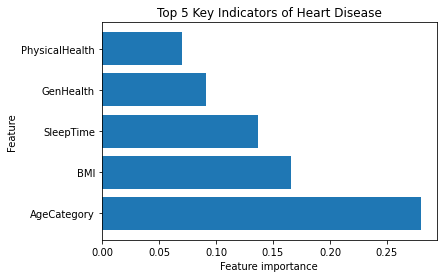

In [ ]:
# Extract the top 5 features and their scores
top_k = 5
feature_importances = rf.feature_importances_
sorted_indices = feature_importances.argsort()[::-1][:top_k]
top_k_features = X.columns[sorted_indices]
top_k_scores = feature_importances[sorted_indices]

# Plot the horizontal bar chart
plt.barh(range(top_k), top_k_scores, align='center')
plt.yticks(range(top_k), top_k_features)
plt.xlabel('Feature importance')
plt.ylabel('Feature')
plt.title(f'Top {top_k} Key Indicators of Heart Disease')
plt.show()
